In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

1 Загрузите файл с данными oka2.csv

In [56]:
data = pd.read_csv('./oka2.csv')

2 Определите, какие количественные показатели различаются у людей с АГ и без АГ

Делю на две выборки независимые выборки с АГ и без АГ

In [57]:
group_ah = data[data["AH"] == "yes"]
group_no_ah = data[data["AH"] == "not"]

In [58]:
numeric = data.select_dtypes(include=[np.number]).columns.drop('N', errors='ignore').tolist()
print(numeric)

['Age', 'Height', 'Weight', 'Waist', 'Hip', 'BMI', 'BSA', 'AD1', 'AD2', 'Hemoglobin', 'Leukocytes', 'Erythrocyte', 'Platelets', 'ESR', 'Hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW-CV', 'RDW-SD', 'MPV', 'PDW', 'PCT', 'Glucose', 'Creatinine', 'SRP', 'T.protein', 'Uric_acid', 'GRACE', 'HR']


Согласно Центральной предельной теореме, стравнивать буду тестом студента, требующий нормальности средних. Группы рассматриваемые в выборказ сильно больше упомянутых на лекции условных n>30. Так как размеры подгрупп разные и внутри них различается дисперсия, возьму тест Уэлча. Так надежнее

In [59]:
results = []
for col in numeric:
    gr_ah = group_ah[col].dropna()
    gr_no_ah = group_no_ah[col].dropna()
    stat, p_value = stats.ttest_ind(gr_ah, gr_no_ah, equal_var=False)
    results.append({
        'column': col,
        'statistic': stat,
        'p_value': p_value,
        "Среднее (с АГ)": np.mean(gr_ah),
        "Среднее (без АГ)": np.mean(gr_no_ah)
    })

df_res = pd.DataFrame(results)
#так как множественные сравнения, используем корректировку Холма во избежание ошибки первого рода
reject, p_corrected, _, _ = multipletests(df_res["p_value"],
                                           alpha=0.05,
                                             method="holm") 
df_res["p-value (скоррект.)"] = p_corrected
df_res["Значимо"] = reject
df_res

,column,statistic,p_value,Среднее (с АГ),Среднее (без АГ),p-value (скоррект.),Значимо
0,Age,7.219988,8.063909e-11,62.299807,54.158537,2.338534e-09,True
1,Height,-4.167996,6.033799e-05,169.783366,173.743902,1.568788e-03,True
2,Weight,1.238036,2.181553e-01,83.961315,82.060976,1.000000e+00,False
3,Waist,2.410376,1.752236e-02,96.675048,93.707317,4.205366e-01,False
4,Hip,2.107563,3.690408e-02,102.528046,100.670732,8.275190e-01,False
5,BMI,4.322695,3.146916e-05,29.092265,27.158312,8.496672e-04,True
6,BSA,-0.719722,4.731498e-01,1.948377,1.963173,1.000000e+00,False
7,AD1,10.360149,8.003367e-19,146.818182,126.585366,2.401010e-17,True
8,AD2,6.653554,7.925479e-10,85.270793,78.475610,2.219134e-08,True
9,Hemoglobin,-0.850394,3.969522e-01,142.266925,143.926829,1.000000e+00,False


Вывод:
В основном различаются:
Height, рост, в среднем ниже у людей с АГ;
BMI, как индекс массы тела, в среднем выше у людей с АГ;
Age, возраст, люди с АГ в среднем старше, 62 против 54 года;
Артериальные давления, AD1 и AD2, выше у людей с АГ, это возможно симптом АГ.

То есть люди с пожилые низкие люди с повышеным имт находятся в группе риска. 

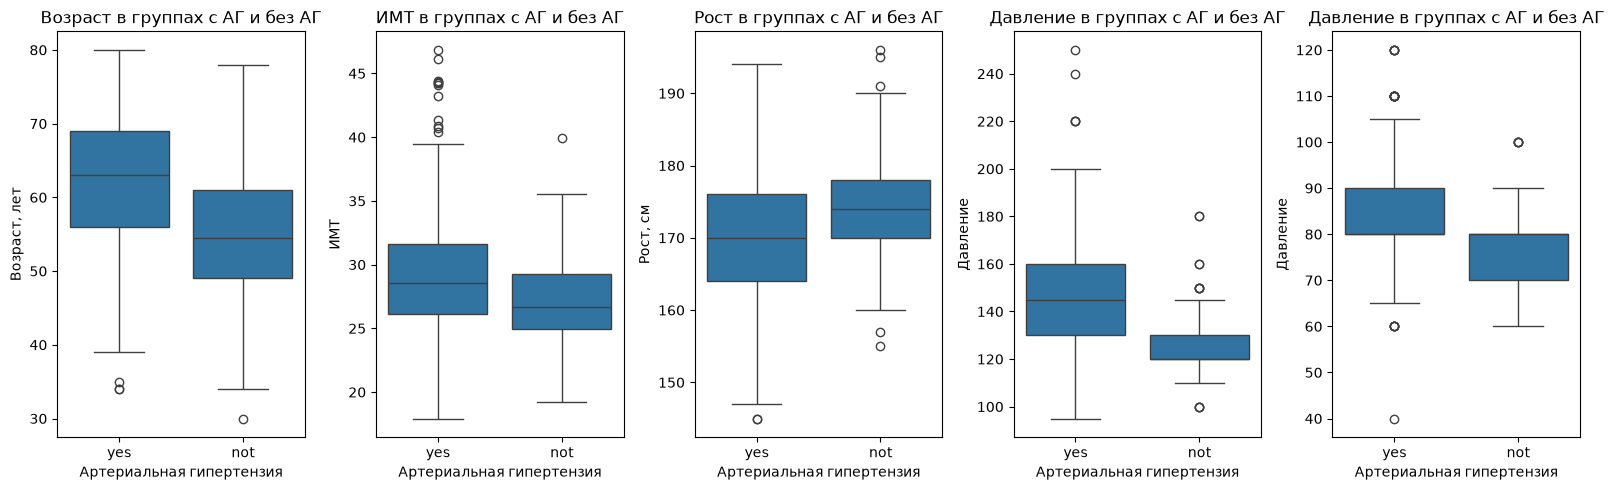

In [67]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

sns.boxplot(data=data, x="AH", y="Age", ax=axes[0])
axes[0].set_title("Возраст в группах с АГ и без АГ")
axes[0].set_xlabel("Артериальная гипертензия")
axes[0].set_ylabel("Возраст, лет")

sns.boxplot(data=data, x="AH", y="BMI", ax=axes[1])
axes[1].set_title("ИМТ в группах с АГ и без АГ")
axes[1].set_xlabel("Артериальная гипертензия")
axes[1].set_ylabel("ИМТ")

sns.boxplot(data=data, x="AH", y="Height", ax=axes[2])
axes[2].set_title("Рост в группах с АГ и без АГ")
axes[2].set_xlabel("Артериальная гипертензия")
axes[2].set_ylabel("Рост, см")

sns.boxplot(data=data, x="AH", y="AD1", ax=axes[3])
axes[3].set_title("Давление в группах с АГ и без АГ")
axes[3].set_xlabel("Артериальная гипертензия")
axes[3].set_ylabel("Давление")

sns.boxplot(data=data, x="AH", y="AD2", ax=axes[4])
axes[4].set_title("Давление в группах с АГ и без АГ")
axes[4].set_xlabel("Артериальная гипертензия")
axes[4].set_ylabel("Давление")

plt.tight_layout()
plt.show()

3 Выявите факторы, взаимосвязанные с АГ

In [60]:
cat = data.select_dtypes(include=['object']).columns.tolist()
print(cat)

['Sex', 'Smoker', 'ICC', 'AH', 'COPD', 'AB', 'Gout', 'CP', 'ICD', 'PU ', 'Gastritis', 'Pancreatitis', 'Diabetes', 'Tiroides', 'VD', 'Stenosis', 'OPKA']


/tmp/ipykernel_1729063/3702466643.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = data.select_dtypes(include=['object']).columns.tolist()


Так как данных мало, будет использовать критерий x^2

In [61]:
results_cat = []

for col in cat:
    if col == "AH":
        continue
    dt = data[["AH", col]].dropna()
    table = pd.crosstab(dt["AH"], dt[col])

    chi2, p_chi2, dof, expected = stats.chi2_contingency(table)

    p_value = p_chi2
    test_name = "Хи-квадрат Пирсона"

    results_cat.append({
        "Фактор": col,
        "Критерий": test_name,
        "p-value": p_value,
        "Минимальная ожидаемая частота": expected.min(),
        "n": len(dt)
    })

df_cat = pd.DataFrame(results_cat)
#так как множественные сравнения, используем корректировку Холма во избежание ошибки первого рода
reject, p_corrected, _, _ = multipletests(df_cat["p-value"],
                                          alpha=0.05,
                                          method="holm")

df_cat["p-value скоррект."] = p_corrected
df_cat["Значимо"] = reject
df_cat

,Фактор,Критерий,p-value,Минимальная ожидаемая частота,n,p-value скоррект.,Значимо
0,Sex,Хи-квадрат Пирсона,0.073116,30.801336,599,1.000000,False
1,Smoker,Хи-квадрат Пирсона,0.371553,26.968280,599,1.000000,False
2,ICC,Хи-квадрат Пирсона,0.051911,16.016694,599,0.778660,False
3,COPD,Хи-квадрат Пирсона,1.000000,1.779633,599,1.000000,False
4,AB,Хи-квадрат Пирсона,0.793467,1.232053,599,1.000000,False
5,Gout,Хи-квадрат Пирсона,0.963198,3.422371,599,1.000000,False
6,CP,Хи-квадрат Пирсона,0.475047,4.928214,599,1.000000,False
7,ICD,Хи-квадрат Пирсона,0.236431,9.719533,599,1.000000,False
8,PU,Хи-квадрат Пирсона,0.600372,6.707846,599,1.000000,False
9,Gastritis,Хи-квадрат Пирсона,0.430597,15.879800,599,1.000000,False


In [62]:
table

OPKA,not,yes
AH,,
not,31,51
yes,210,307


p < 0.05 у всех категориальных переменных, однако до мультитесткоректора Холма была p value < 0.05 у диабета. Следовательно нулевая гипотеза отвеграется и статистически значемой связи с AH не обнаружено. Однако возможна связь между AH и диабетом.